In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configure matplotlib for better performance with large datasets
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5

In [2]:
# Function to calculate fitness with hardcoded equations
def calculate_fitness(equations1, equations2, registro):
    """
    Calculate fitness based on the system of equations.
    fitness = sum(weights[i] * equations[i](digits[i])) for i in range(len(digits))
    
    Modify the weights and equations lists below as needed for your experiments.
    digits[0] = x1 (least significant digit, rightmost)
    digits[n-1] = xn (most significant digit, leftmost)
    """
            
    # Calculate fitness by iterating over the 3 lists
    fitness1, fitness2 = 0, 0
    
    for equation in equations1:
        fitness1 += equation(registro)

    for equation in equations2:
        fitness2 += equation(registro)
    
    return fitness1, fitness2


# Function to display plots of fitness landscape for 2 objectives
def display_fitness_landscape(df):
    '''
    Plots the fitness landscape for 2 objectives
    df: pandas DataFrame with the fitness values
    '''

    # Plot fitness1 vs registro (Gráfico de Área)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.fill_between(df['registro'], df['fitness1'], alpha=0.6, color='steelblue', edgecolor='darkblue', linewidth=0.5)
    ax.set_xlabel('Registro', fontsize=12)
    ax.set_ylabel('Fitness1', fontsize=12)
    ax.set_title('Fitness Landscape: Fitness1 vs Registro', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot fitness2 vs registro (Gráfico de Área)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.fill_between(df['registro'], df['fitness2'], alpha=0.6, color='coral', edgecolor='darkred', linewidth=0.5)
    ax.set_xlabel('Registro', fontsize=12)
    ax.set_ylabel('Fitness2', fontsize=12)
    ax.set_title('Fitness Landscape: Fitness2 vs Registro', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot fitness_full, fitness1, fitness2 (Gráfico de Linha)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(df['registro'], df['fitness_full'], alpha=0.8, color='purple', linewidth=1.5, label='Fitness Full')
    ax.plot(df['registro'], df['fitness1'], alpha=0.7, color='steelblue', linewidth=1, label='Fitness1')
    ax.plot(df['registro'], df['fitness2'], alpha=0.7, color='coral', linewidth=1, label='Fitness2')
    ax.set_xlabel('Registro', fontsize=12)
    ax.set_ylabel('Fitness', fontsize=12)
    ax.set_title('Fitness Landscape: Comparação de Fitness (Full, Fitness1, Fitness2)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [3]:
equations1 = [
    lambda x: (x/100000)**2 / 20,
    lambda x: 5 * np.cos(x/500000),
    lambda x: 4 * np.sin(x/100000),
    lambda x: 3 * np.cos(x/25000),
    lambda x: 2 * np.cos(x/4000),
    lambda x:     np.sin(x/2000),
    lambda x: np.maximum(0, 3 * np.cos(2.3+ (x/10000))),
    lambda x: np.maximum(0, 3 * np.sin(1  + (x/10000))),
    lambda x: 5,
]

equations2 = [
    lambda x: (x/70000)**2 / 15,
    lambda x: 2 * np.sin(x/1000000),
    lambda x: 2 * np.cos(x/300000),
    lambda x: 2 * np.cos(x/50000),
    lambda x:     np.sin(x/20000),
    lambda x:     np.cos(x/8000),
    lambda x: np.minimum(0, 3 * np.cos(2.3+ (x/10000))),
    lambda x: np.minimum(0, 3 * np.sin(1  + (x/10000))),
    lambda x: 5,
]

total_records = 1000000

1000000
[     0      1      2 ... 999997 999998 999999]
 


100%|██████████| 1000000/1000000 [00:26<00:00, 38132.89it/s]


,registro,fitness1,fitness2,fitness_full
0,0,17.524413,8.001172,25.525585
1,1,17.525115,8.001000,25.526115
2,2,17.525817,8.000829,25.526645


,registro,fitness1,fitness2,fitness_full
999997,999997,5.112083,19.076239,24.188322
999998,999998,5.112272,19.076063,24.188335
999999,999999,5.112461,19.075887,24.188348


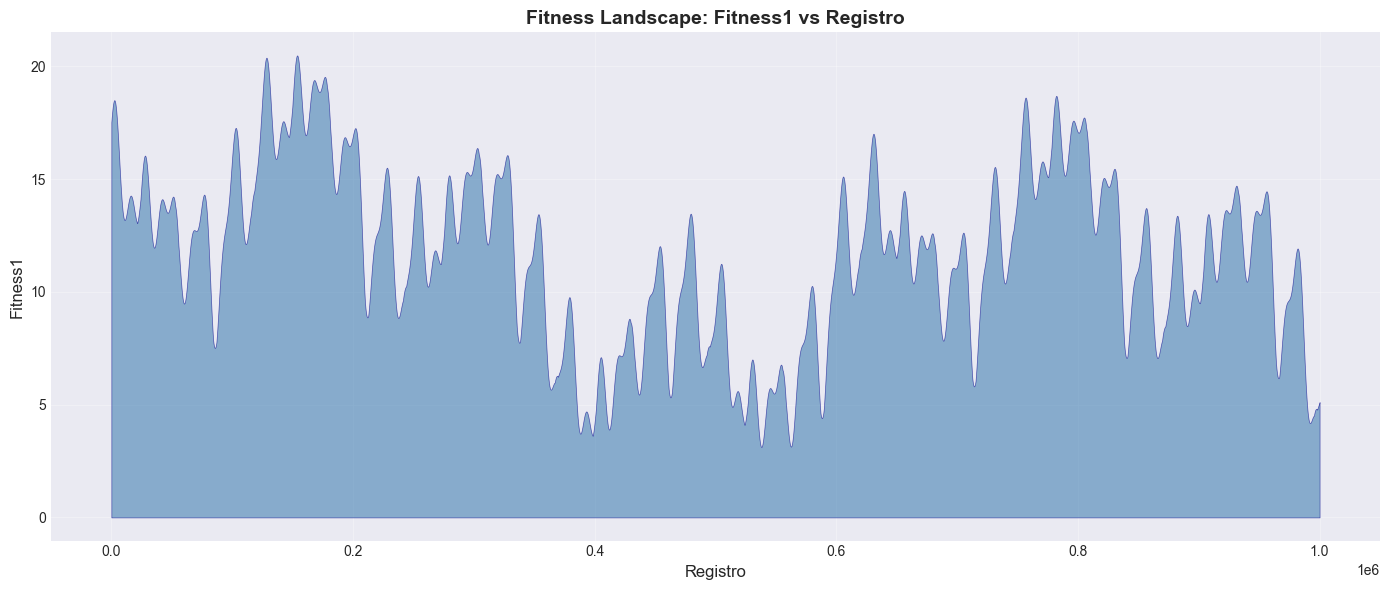

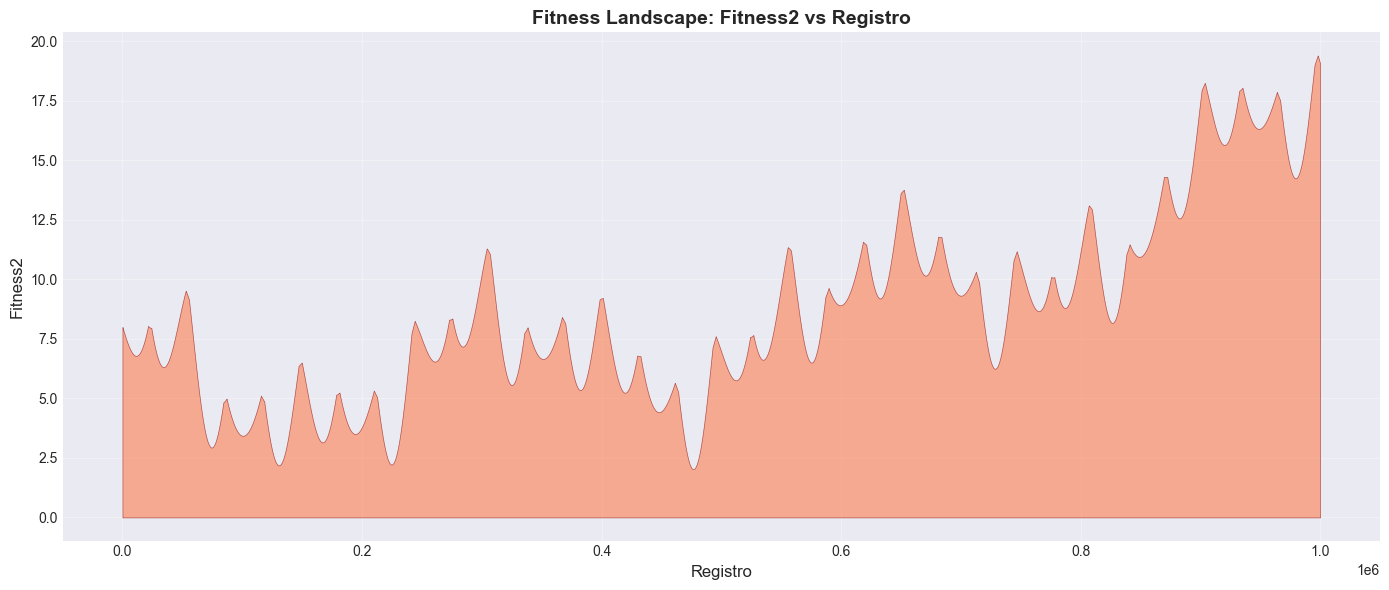

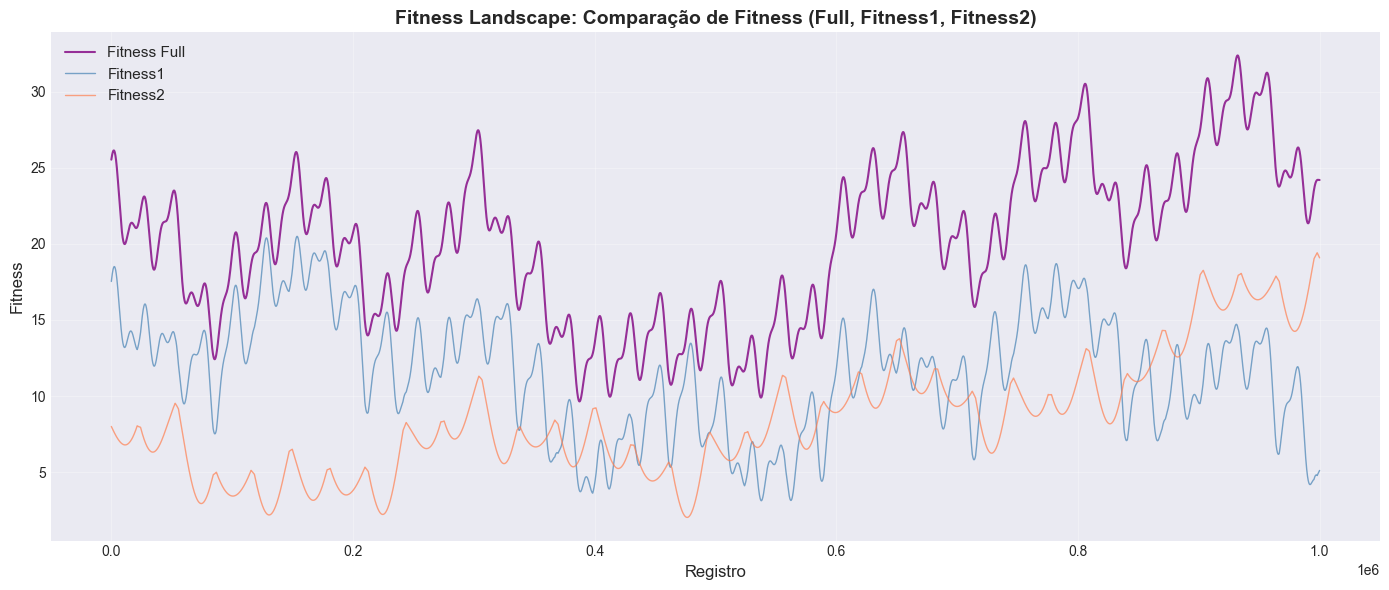

In [4]:
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
print(len(registros))
print(registros)
print(' ')


# Create the dataset with progress bar
data = []
for registro in tqdm(registros):
    fitness1, fitness2 = calculate_fitness(equations1, equations2, registro)        
    row = [registro, fitness1, fitness2]
    data.append(row)

# Create DataFrame
columns = ['registro', 'fitness1', 'fitness2'] 
df = pd.DataFrame(data, columns=columns)
df['fitness_full'] = df['fitness1'] + df['fitness2']

display(df.head(3))
display(df.tail(3))
display_fitness_landscape(df)
